# =============================================================================
# PARTIE 3 — Prédiction de genre & recommandation depuis les synopsis avec réseaux de neuronnes
# =============================================================================


In [1]:
# ─── 1. Chargement et EDA ────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("movie_plots.csv")
print(data.shape)
print(data.head())
print(data.info())

data.isnull().sum()

(5385, 3)
   movie_poster_path                                         movie_plot  \
0  action/100108.jpg  The movie "Parker" is a thrilling action film ...   
1  action/100192.jpg  The movie "Ironclads" is a historical drama se...   
2  action/100404.jpg  The movie "Rainy Dog" is a gripping and intens...   
3  action/101761.jpg  Welcome to the Punch is a thrilling action fil...   
4  action/102051.jpg  The movie "Iron Man: Rise of Technovores" is a...   

  movie_category  
0         action  
1         action  
2         action  
3         action  
4         action  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5385 entries, 0 to 5384
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   movie_poster_path  5385 non-null   object
 1   movie_plot         5385 non-null   object
 2   movie_category     5385 non-null   object
dtypes: object(3)
memory usage: 126.3+ KB
None


movie_poster_path    0
movie_plot           0
movie_category       0
dtype: int64

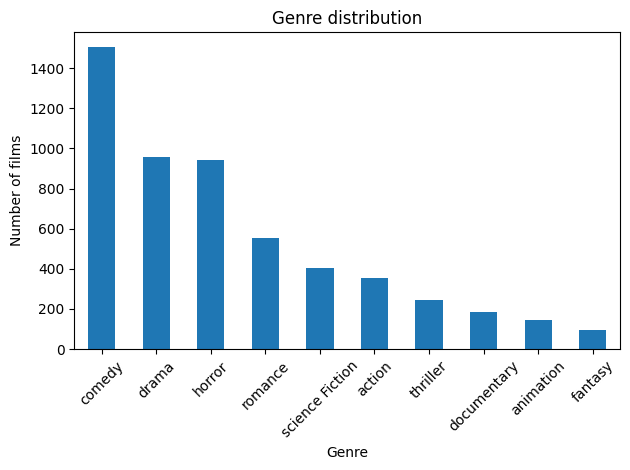

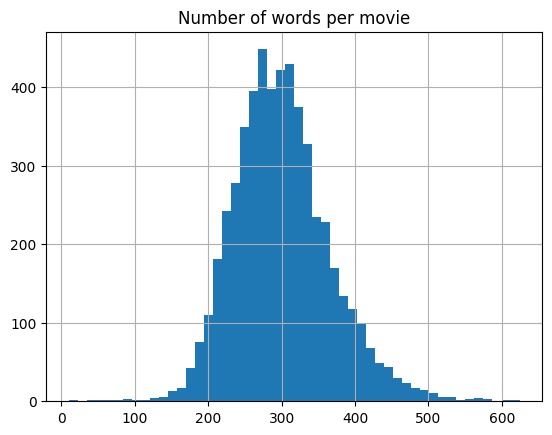

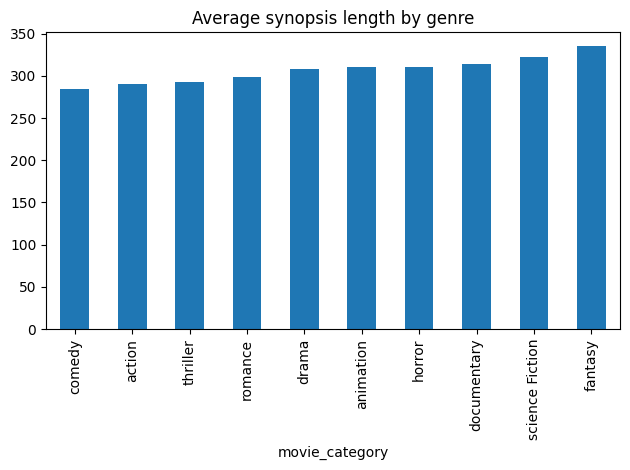

In [3]:
# Distribution des genres
data['movie_category'].value_counts().plot(kind='bar')
plt.title("Genre distribution")
plt.xlabel("Genre")
plt.ylabel("Number of films")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Longueur des synopsis
data['plot_length'] = data["movie_plot"].apply(len)
data['word_count'] = data['movie_plot'].apply(lambda x: len(x.split()))
data['word_count'].hist(bins=50)
plt.title("Number of words per movie")
plt.show()

data.groupby('movie_category')['word_count'].mean().sort_values().plot(kind='bar')
plt.title("Average synopsis length by genre")
plt.tight_layout()
plt.show()


# 2.Tokenisation et construction du vocabulaire  ───────────────────────────────────────────────


In [4]:
import string
import re
from collections import Counter
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def improved_tokenizer(text):
    # Lowercase
    text = text.lower()
    # Suppression des chiffres
    text = re.sub(r'\d+', '', text)
    # Suppression de la ponctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenisation + suppression stopwords
    tokens = [t for t in text.strip().split() if t not in stop_words and len(t) > 1]
    return tokens

# Appliquer sur tes données
data["tokens"] = data["movie_plot"].apply(improved_tokenizer)  # adapte le nom de colonne

# Construire le vocabulaire avec filtre de fréquence minimale
counter = Counter()
for tokens in data["tokens"]:
    counter.update(tokens)

MIN_FREQ = 2
vocab = ["<unk>", "<pad>"] + [word for word, freq in counter.items() if freq >= MIN_FREQ]
stoi = {word: idx for idx, word in enumerate(vocab)}
itos = {idx: word for word, idx in stoi.items()}

import pickle
with open("vocab.pkl", "wb") as f:
    pickle.dump(stoi, f)
print("Vocabulaire sauvegardé !")

print(f"Taille du vocabulaire : {len(vocab)}")
print(f"Exemple de tokens : {data['tokens'].iloc[0][:10]}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\cesar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Vocabulaire sauvegardé !
Taille du vocabulaire : 15672
Exemple de tokens : ['movie', 'parker', 'thrilling', 'action', 'film', 'follows', 'story', 'parker', 'former', 'assassin']


# 3. Préparation des données ───────────────────────────────────────────────


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle

In [6]:
data_nlp = data.drop('movie_poster_path', axis=1)

train_data, test_data = train_test_split(
    data_nlp,
    test_size=0.2,
    stratify=data_nlp['movie_category'],
    random_state=42
)

In [7]:
le = LabelEncoder()
train_data = train_data.copy()
test_data = test_data.copy()
train_data['label'] = le.fit_transform(train_data['movie_category'])
test_data['label'] = le.transform(test_data['movie_category'])

mapping = dict(zip(le.transform(le.classes_), le.classes_))
print("Mapping genres :", mapping)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print("LabelEncoder sauvegardé dans label_encoder.pkl")

train_data = train_data[["tokens", "label"]].to_dict(orient="records")
test_data = test_data[["tokens", "label"]].to_dict(orient="records")

print(f"Train : {len(train_data)} exemples")
print(f"Test  : {len(test_data)} exemples")
print(f"Exemple : {train_data[0]}")



Mapping genres : {np.int64(0): 'action', np.int64(1): 'animation', np.int64(2): 'comedy', np.int64(3): 'documentary', np.int64(4): 'drama', np.int64(5): 'fantasy', np.int64(6): 'horror', np.int64(7): 'romance', np.int64(8): 'science Fiction', np.int64(9): 'thriller'}
LabelEncoder sauvegardé dans label_encoder.pkl
Train : 4308 exemples
Test  : 1077 exemples
Exemple : {'tokens': ['movie', 'inherit', 'wind', 'satirical', 'comedy', 'takes', 'place', 'scopes', 'monkey', 'trial', 'famous', 'legal', 'case', 'united', 'states', 'story', 'revolves', 'around', 'small', 'town', 'tennessee', 'local', 'schoolteacher', 'tom', 'robinson', 'played', 'spencer', 'tracy', 'accused', 'teaching', 'evolution', 'instead', 'bible', 'trial', 'becomes', 'media', 'sensation', 'local', 'newspaper', 'tennessee', 'times', 'playing', 'significant', 'role', 'proceedings', 'film', 'follows', 'trial', 'various', 'angles', 'including', 'perspective', 'defense', 'team', 'includes', 'lawyer', 'named', 'john', 'scopes', 'p

# 4. Creating a Custom DataLoader for Texts ───────────────────────────────────────────────


In [8]:
import torch
from torch.utils.data import DataLoader
import torch.nn as nn 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [9]:
def text_to_tensor(tokens):
    return torch.tensor([stoi.get(token,stoi["<unk>"]) for token in tokens], dtype=torch.int64)

def collate_batch(batch):
    label_list, text_list, lengths = [],[],[]
    for example in batch :
        label = example["label"]
        tokens = example["tokens"]
        tensor = text_to_tensor(tokens)
        label_list.append(label)
        text_list.append(tensor)
        lengths.append(len(tensor))
    text_tensor = nn.utils.rnn.pad_sequence(text_list, batch_first=True)
    label_tensor = torch.tensor(label_list, dtype=torch.int64)
    lengths_tensor = torch.tensor(lengths, dtype=torch.int64)
    return text_tensor.to(device), label_tensor.to(device), lengths_tensor.to(device)

train_loader = DataLoader(train_data, batch_size=8, shuffle=True, collate_fn = collate_batch)
test_loader = DataLoader(test_data, batch_size=8, shuffle=False, collate_fn=collate_batch)

In [10]:
for batch_texts, batch_labels, batch_lengths in train_loader:
    print(batch_texts.shape, batch_labels.shape, batch_lengths.shape)
    break

torch.Size([8, 187]) torch.Size([8]) torch.Size([8])


# 5. Designing the Neural Network Classifier Bag-Of-Words 

In [11]:
from torch import nn

class TextClassificationModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_class, use_pre_trained=False):
        super(TextClassificationModel, self).__init__()
        if use_pre_trained :
            self.embedding = nn.Embedding.from_pretrained(weights_matrix, freeze=True)
        else : 
            self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.fc = nn.Linear(embed_dim, num_class)
    def get_embeddings(self,text):
        embedded = self.embedding(text)
        return torch.mean(embedded,1)
    def forward(self, text):
        embedded = self.get_embeddings(text)
        return self.fc(embedded)


In [12]:
from tqdm import tqdm

def train(model, dataloader, optimizer, criterion, epochs=5):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        running_corrects = 0
        total =0
        t = tqdm(dataloader)
        for i, (text, labels, text_lengths) in enumerate(t):
            pred = model(text)
            loss = criterion(pred, labels)
            _, predicted = pred.max(1)
            running_corrects += predicted.eq(labels).sum().item()
            total += labels.size(0)
            running_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            t.set_description(f"epoch:{epoch} loss:{(running_loss / (i+1)):4f} currend accuracy:{round(running_corrects / total * 100,2)}%")


def test(model, dataloader):
    model.eval()
    test_corrects =0
    total = 0
    with torch.no_grad():
        for text, labels, text_lengths  in dataloader : 
            pred = model(text)
            _, predicted = pred.max(1)
            test_corrects += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return test_corrects / total 



In [13]:
LR = 0.005
num_class = 10
vocab_size = len(itos)
embedding_dim = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TextClassificationModel(vocab_size, embedding_dim, num_class).to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
train(model, train_loader, optimizer, criterion, epochs=3)
test(model, test_loader)

epoch:2 loss:0.136805 currend accuracy:96.7%: 100%|██████████| 539/539 [00:08<00:00, 63.23it/s]  


0.914577530176416

In [14]:
pip install annoy


  Using cached annoy-1.17.3.tar.gz (647 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for annoy: filename=annoy-1.17.3-cp311-cp311-win_amd64.whl size=54452 sha256=58074987e980d5adce9878365be8cdacf7a33457a65c9b881d85523ba150e26e
  Stored in directory: c:\users\cesar\appdata\local\pip\cache\wheels\6f\b7\de\ac2140ac002f1205a2585937fa08a096ad3f23a8a7dd4b0976
Successfully built annoy
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from annoy import AnnoyIndex

# ─── Sauvegarde des poids ────────────────────────────────────────────────────
torch.save(model.state_dict(), "model_weights_bag_of_words.pth")
print("Poids sauvegardés dans model_weights.pth")

# ─── Sauvegarde des embeddings ───────────────────────────────────────────────
embeddings = model.embedding.weight.detach().cpu()
torch.save(embeddings, "embeddings_bag_of_words.pth")
print(f"Embeddings sauvegardés : {embeddings.shape}")

# ─── Création de l'index Annoy ───────────────────────────────────────────────
annoy_index = AnnoyIndex(embedding_dim, metric='angular')

for idx, vector in enumerate(embeddings):
    annoy_index.add_item(idx, vector.numpy())

annoy_index.build(n_trees=10)
annoy_index.save("annoy_index_bag_of_words.ann")
print("Index Annoy sauvegardé dans annoy_index.ann")

Poids sauvegardés dans model_weights.pth
Embeddings sauvegardés : torch.Size([15672, 100])
Index Annoy sauvegardé dans annoy_index.ann


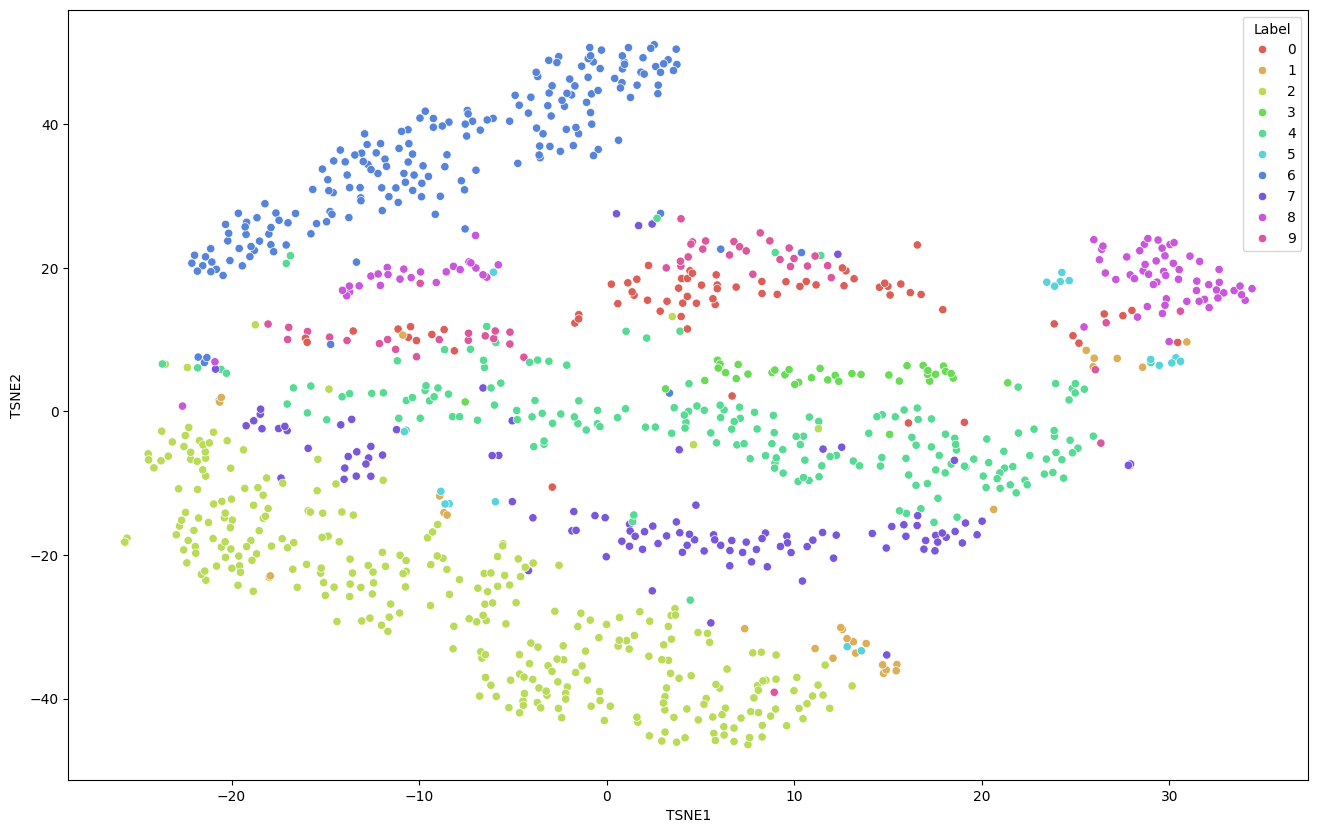

In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import pandas as pd

embeddings, labels = [], []
for texts, label, _ in test_loader:
    with torch.no_grad():
        embeddings.append(model.get_embeddings(texts).cpu().numpy())
        labels.extend(label.cpu().numpy())

embeddings = np.vstack(embeddings)
labels = np.array(labels)

X_tsne = TSNE(n_components=2, random_state=0).fit_transform(embeddings)

plot_data = pd.DataFrame({'TSNE1': X_tsne[:, 0], 'TSNE2': X_tsne[:, 1], 'Label': labels})
plt.figure(figsize=(16, 10))
sns.scatterplot(x="TSNE1", y="TSNE2", hue="Label", palette=sns.color_palette("hls", len(np.unique(labels))), data=plot_data, legend="full")
plt.show()


# 6. Adding Recurrence with LSTM Layers 

In [35]:
import torch.nn as nn

class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, output_dim=10):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim,
                            100,
                            num_layers=2,
                            dropout=0.2,
                            batch_first=True)
        self.fc = nn.Linear(100, output_dim)
    def forward(self,text,text_lengths):
        embedded = self.get_embeddings(text, text_lengths)
        outputs = self.fc(embedded)
        return outputs
    def get_embeddings(self, text, text_lengths):
        embedded = self.embedding(text)
        packed_embedded = nn.utils.rnn.pack_padded_sequence(embedded, text_lengths.cpu(), batch_first=True, enforce_sorted=False)
        _,(hidden, cell) = self.lstm(packed_embedded)
        return hidden[-1]


In [36]:
def train(model, dataloader, optimizer, criterion, epochs=3):
  model.train()
  for epoch in range(epochs):
    running_loss = 0.0
    running_corrects = 0
    total = 0
    t = tqdm(dataloader)
    for i, (text, labels, text_lengths) in enumerate(t):

      pred = model(text, text_lengths).squeeze() #convert to 1D tensor
      loss = criterion(pred, labels)

      _, predicted = pred.max(1)
      running_corrects += predicted.eq(labels).sum().item()
      total += labels.size(0)
      running_loss += loss.item()

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      t.set_description(f"epoch:{epoch} loss: {(running_loss / (i+1)):.4f} current accuracy:{round(running_corrects / total * 100, 2)}%")

def test(model, dataloader):
  model.eval()
  test_corrects = 0
  total = 0
  with torch.no_grad():
      for text, labels, text_lengths in dataloader:
          pred = model(text, text_lengths).squeeze()
          _, predicted = pred.max(1)
          test_corrects += predicted.eq(labels).sum().item()
          total += labels.size(0)
  return test_corrects / total

In [38]:
LR = 0.001
model = TextClassifier(vocab_size, 128, len(le.classes_)).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
train(model, train_loader, optimizer, criterion, epochs=5)
test(model, test_loader)

  0%|          | 0/135 [00:00<?, ?it/s]

epoch:4 loss: 0.4463 current accuracy:86.07%: 100%|██████████| 135/135 [02:26<00:00,  1.08s/it]


0.7808727948003714

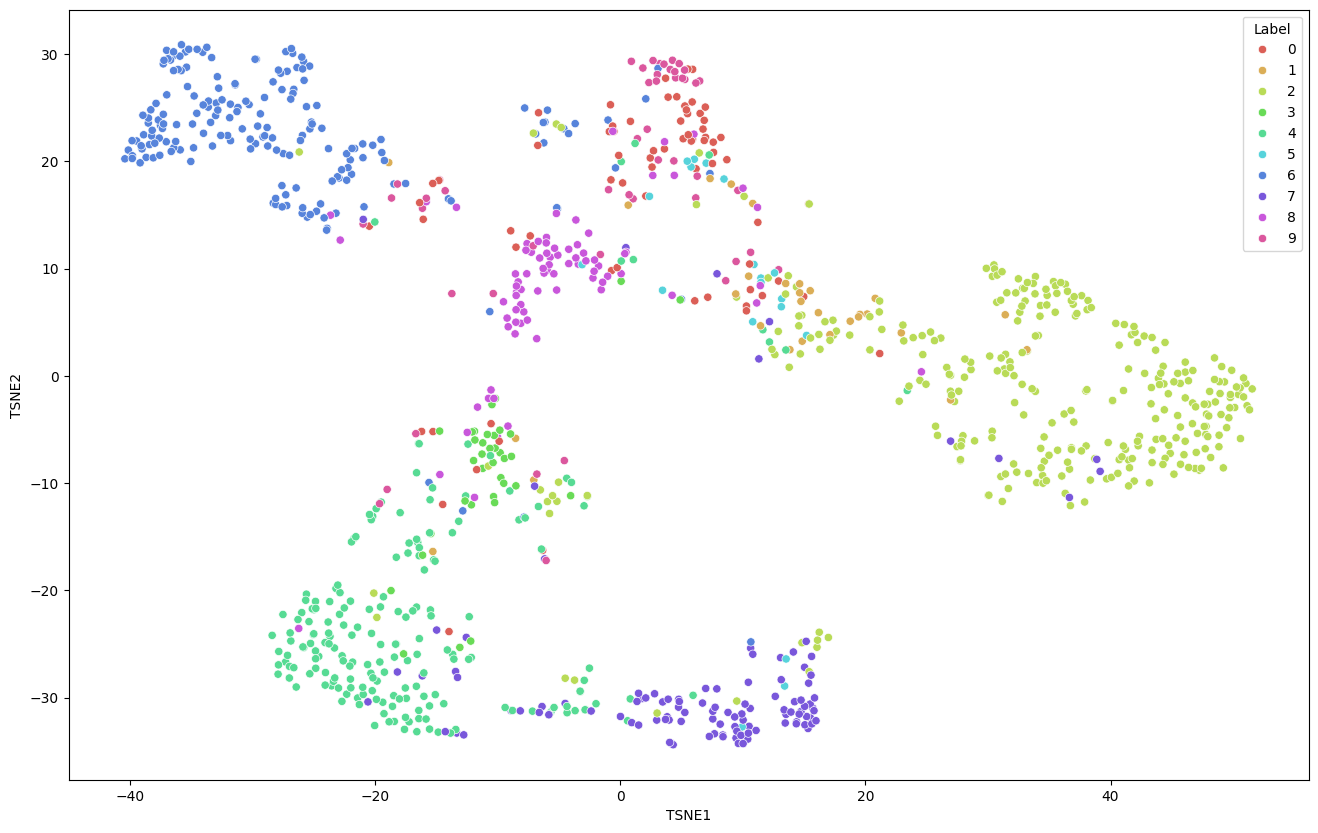

In [39]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import pandas as pd

embeddings, labels = [], []
for texts, label, text_lengths in test_loader:
    with torch.no_grad():
        embeddings.append(model.get_embeddings(texts, text_lengths).cpu().numpy())
        labels.extend(label.cpu().numpy())

embeddings = np.vstack(embeddings)
labels = np.array(labels)

X_tsne = TSNE(n_components=2, random_state=0).fit_transform(embeddings)

plot_data = pd.DataFrame({'TSNE1': X_tsne[:, 0], 'TSNE2': X_tsne[:, 1], 'Label': labels})
plt.figure(figsize=(16, 10))
sns.scatterplot(x="TSNE1", y="TSNE2", hue="Label", palette=sns.color_palette("hls", len(np.unique(labels))), data=plot_data, legend="full")
plt.show()

In [40]:
# ─── Sauvegarde des poids ────────────────────────────────────────────────────
torch.save(model.state_dict(), "model_weights_lstm.pth")
print("Poids sauvegardés dans model_weights_lstm.pth")

# ─── Sauvegarde des embeddings ───────────────────────────────────────────────
embeddings_lstm = model.embedding.weight.detach().cpu()
torch.save(embeddings_lstm, "embeddings_lstm.pth")
print(f"Embeddings sauvegardés : {embeddings_lstm.shape}")

# ─── Création de l'index Annoy ───────────────────────────────────────────────
annoy_index_lstm = AnnoyIndex(128, metric='angular')  # 128 = embedding_dim

for idx, vector in enumerate(embeddings_lstm):
    annoy_index_lstm.add_item(idx, vector.numpy())

annoy_index_lstm.build(n_trees=10)
annoy_index_lstm.save("annoy_index_lstm.ann")
print("Index Annoy sauvegardé dans annoy_index_lstm.ann")

Poids sauvegardés dans model_weights_lstm.pth
Embeddings sauvegardés : torch.Size([15672, 128])
Index Annoy sauvegardé dans annoy_index_lstm.ann


In [42]:
# ─── Test de recommandation avec Annoy ───────────────────────────────────────
from annoy import AnnoyIndex
import numpy as np

# Recharger l'index
annoy_index_lstm = AnnoyIndex(128, metric='angular')
annoy_index_lstm.load("annoy_index_lstm.ann")

# Fonction : synopsis → vecteur moyen
def get_movie_vector(plot_text):
    tokens = improved_tokenizer(plot_text)
    indices = [stoi.get(t, stoi["<unk>"]) for t in tokens]
    if len(indices) == 0:
        return np.zeros(128)
    vectors = embeddings_lstm[indices].numpy()
    return vectors.mean(axis=0)

# Construire les vecteurs de tous les films
print("Construction des vecteurs films...")
movie_vectors = np.vstack([get_movie_vector(plot) for plot in data["movie_plot"]])

# Choisir un film test
film_idx = 0
film_title = data["movie_plot"].iloc[film_idx][:60]
film_genre = data["movie_category"].iloc[film_idx]
print(f"\nFilm de référence : {film_title}...")
print(f"Genre : {film_genre}")

# Chercher les 5 films les plus similaires
query_vector = movie_vectors[film_idx]
distances = np.linalg.norm(movie_vectors - query_vector, axis=1)
top5_idx = np.argsort(distances)[1:6]  # [1:] pour exclure le film lui-même

print("\n── 5 films recommandés ──")
for i, idx in enumerate(top5_idx):
    print(f"{i+1}. {data['movie_plot'].iloc[idx][:60]}... | Genre : {data['movie_category'].iloc[idx]}")

Construction des vecteurs films...

Film de référence : The movie "Parker" is a thrilling action film that follows t...
Genre : action

── 5 films recommandés ──
1. The movie "Parker" is an action thriller that follows the st... | Genre : action
2. In this comedy film, Whoopi Goldberg stars as a former profe... | Genre : comedy
3. Combat Shock is an intense action film set in a dystopian fu... | Genre : action
4. In the heart of the American Southwest during the 1930s, Dja... | Genre : drama
5. The movie "Boarding Gate" is a thrilling action-thriller set... | Genre : thriller
